In [1]:
import numpy as np
from fractions import Fraction
from scipy.integrate import quad
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import os

######################### Compute DTER in aligned ECM ##########################

mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",
})

########################## Fixed model parameters ##############################

alpha_a = 1.0
alpha_m = 1.0
d = 1.0
phi = 1.0
beta = 500.0
k = 500 * np.sqrt(2)

############################# Helper functions #################################

def pi_fraction_label(x, max_den=8):
    frac = Fraction(x / np.pi).limit_denominator(max_den)

    if frac == 0:
        return r"0"
    elif frac == 1:
        return r"\pi"
    elif frac.numerator == 1:
        return rf"\pi/{frac.denominator}"
    else:
        return rf"{frac.numerator}\pi/{frac.denominator}"

def g(beta, phi, k): 
    return phi * (beta / k) * np.exp(-(beta / k)**2)

def p_min(theta, n_p):
    return n_p * (1/np.pi) * (1 - theta/np.pi)**(n_p - 1)

def a(theta, theta0=0.0, gamma=1.0):
    base = 0.5 * (1.0 + np.cos(theta - theta0))  # in [0,1]
    raw = base**gamma

    norm, _ = quad(
        lambda th: (0.5 * (1.0 + np.cos(th - theta0)))**gamma * (1/np.pi),
        0, np.pi
    )
    return raw / norm

def compute_DTER(n_p, l_p, g_val, d_crit, theta0=0.0, gamma=1.0):
    if l_p < d_crit:
        return 0.0

    theta_crit = np.arccos(d_crit / l_p)

    P_det = 1 - (1 - theta_crit/np.pi)**n_p

    if P_det > 0:
        EA_det, _ = quad(lambda th: a(th, theta0, gamma) * p_min(th, n_p), 0, 
                         theta_crit)
        EA_det = EA_det / P_det
    else:
        EA_det = 0.0

    EA_rand, _ = quad(lambda th: a(th, theta0, gamma) * (1/np.pi), 0, np.pi)

    EA_move = P_det * EA_det + (1 - P_det) * EA_rand
    d_avg = d * EA_move

    num_int, _ = quad(lambda th: a(th, theta0, gamma) * np.cos(th) * p_min(th, 
                      n_p), 0, theta_crit)

    numerator = g_val * d * num_int 

    denominator = (
        n_p * l_p**2
        + alpha_a * n_p**2 * l_p**2
        + alpha_m * beta * g_val * d_avg)

    return numerator / denominator if denominator != 0 else 0.0

In [31]:
n_p_values = list(range(1, 11))
l_p_values = list(range(1, 11))
g_val = g(beta, phi, k)
d_crit = 0.8

theta0_values = np.linspace(0.0, np.pi/2, 10)
gamma_values  = np.linspace(0,10,10)

n_gamma = len(gamma_values)
n_theta0 = len(theta0_values)

opt_n_p_grid = np.zeros((n_gamma, n_theta0), dtype=float) 
opt_l_p_grid = np.zeros((n_gamma, n_theta0), dtype=float) 
opt_n_p_l_p_grid = np.zeros((n_gamma, n_theta0), dtype=float) 


for r, gamma in enumerate(gamma_values):
    for c, theta0 in enumerate(theta0_values):        
        DTER_matrix = np.zeros((len(n_p_values), len(l_p_values)))
        for i, n_p in enumerate(n_p_values):
            for j, l_p in enumerate(l_p_values):
                DTER_matrix[i, j] = compute_DTER(n_p, l_p, g_val, d_crit, theta0, gamma)
        # Optimum
        max_idx = np.unravel_index(np.argmax(DTER_matrix), DTER_matrix.shape)
        opt_n, opt_l = max_idx   #### this is the index of n_p and l_p
        opt_n_p_grid[r,c] = n_p_values[opt_n]
        opt_l_p_grid[r,c] = l_p_values[opt_l]
        opt_n_p_l_p_grid[r,c] = n_p_values[opt_n]*l_p_values[opt_l]  #### Could also show opt_n*opt_l

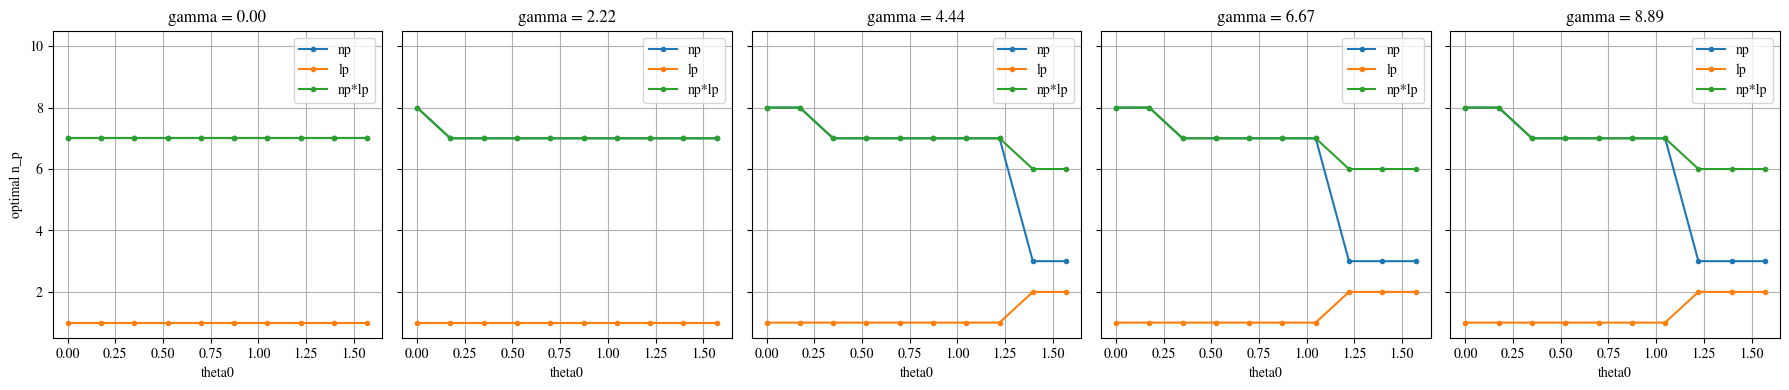

In [33]:
gamma_indices = [0, 2, 4, 6, 8]   

fig, axes = plt.subplots(1, len(gamma_indices), figsize=(18, 4), sharey=True)

for ax, idx in zip(axes, gamma_indices):
    ax.plot(theta0_values, opt_n_p_grid[idx, :], marker='.', label = 'np')
    ax.plot(theta0_values, opt_l_p_grid[idx, :], marker='.', label = 'lp')
    ax.plot(theta0_values, opt_n_p_l_p_grid[idx, :], marker='.', label = 'np*lp')
    ax.legend()
    ax.set_title(f"gamma = {gamma_values[idx]:.2f}")
    ax.set_xlabel("theta0")
    ax.set_ylim(0.5, 10.5)  
    ax.grid(True)

axes[0].set_ylabel("optimal n_p")

plt.tight_layout()
plt.show()